# 02_preprocessing_image.ipynb

## Tiền xử lý ảnh và Ablation Study

Thực hiện các kỹ thuật tiền xử lý ảnh số và đo lường tác động.

In [1]:
import os
import pickle
import numpy as np
import cv2
from sklearn.decomposition import PCA
from scipy import stats as scipy_stats
from scipy.stats import ks_2samp, f_oneway
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Tên các lớp
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Đường dẫn
DATA_PATH = '../data/raw/image-data/data_batch_1'

# Tải ảnh từ pickle file
print('Đang tải ảnh từ data_batch_1...')
with open(DATA_PATH, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

images = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.uint8)
labels = np.array(batch[b'labels'])

print(f'Đã tải {len(images)} ảnh, kích thước: {images.shape}')

# =============================================================================
# Helper Functions
# =============================================================================

def calculate_ssim(img1, img2, L=255):
    """
    Tính SSIM (Structural Similarity Index) thủ công.
    
    Công thức:
    SSIM(x, y) = ((2*ux*uy + C1)*(2*sxy + C2)) / ((ux^2 + uy^2 + C1)*(sx^2 + sy^2 + C2))
    
    Tham số:
    - img1, img2: Hai ảnh cần so sánh (cùng kích thước)
    - L: Giá trị lớn nhất (255 cho ảnh 8-bit)
    
    Trả về:
    - Giá trị SSIM trong khoảng [0, 1]
    """
    # Chuyển về float để tính toán chính xác
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    
    # Hằng số ổn định
    C1 = (0.01 * L) ** 2
    C2 = (0.03 * L) ** 2
    
    # Tính trung bình (mean)
    mu1 = np.mean(img1)
    mu2 = np.mean(img2)
    
    # Tính phương sai (variance)
    var1 = np.var(img1)
    var2 = np.var(img2)
    
    # Tính hiệp phương sai (covariance)
    cov = np.mean((img1 - mu1) * (img2 - mu2))
    
    # Tính SSIM theo công thức
    numerator = (2 * mu1 * mu2 + C1) * (2 * cov + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (var1 + var2 + C2)
    
    if denominator == 0:
        return 1.0  # Hai ảnh giống nhau hoặc là giá trị 0
    
    ssim = numerator / denominator
    
    return ssim

def calculate_psnr(img1, img2, L=255):
    """
    Tính PSNR (Peak Signal-to-Noise Ratio) thủ công.
    
    Công thức:
    PSNR = 10 * log10(L^2 / MSE)
    
    Tham số:
    - img1, img2: Hai ảnh cần so sánh
    - L: Giá trị lớn nhất (255 cho ảnh 8-bit)
    
    Trả về:
    - Giá trị PSNR theo dB
    """
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    
    if mse == 0:
        return 99.99  # Hai ảnh giống nhau
    
    psnr = 10 * np.log10(L**2 / mse)
    return psnr

print("Đã định nghĩa hàm tính SSIM và PSNR thủ công.")

Đang tải ảnh từ data_batch_1...
Đã tải 10000 ảnh, kích thước: (10000, 32, 32, 3)
Đã định nghĩa hàm tính SSIM và PSNR thủ công.


## 2.1.3a Thay đổi kích thước và chất lượng ảnh - Resize + SSIM/PSNR

### (i) Lý thuyết

**SSIM (Structural Similarity Index)** đo lường sự tương đồng cấu trúc giữa hai ảnh, phù hợp với nhận thức thị giác con người hơn các metric đơn giản như MSE.

Công thức chính:
$$SSIM(x, y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$$

Trong đó:
- $\mu_x, \mu_y$: Trung bình cường độ pixel
- $\sigma_x^2, \sigma_y^2$: Phương sai
- $\sigma_{xy}$: Hiệp phương sai giữa hai ảnh
- $C_1 = (0.01 \cdot L)^2, C_2 = (0.03 \cdot L)^2$: Hằng số ổn định, với $L=255$ cho 8-bit images

**PSNR (Peak Signal-to-Noise Ratio)** đo lường tỷ số tín hiệu/nhiễu theo decibel:
$$PSNR = 10 \log_{10}\left(\frac{L^2}{MSE}\right)$$

với:
$$MSE = \frac{1}{MN}\sum_{i=1}^{M}\sum_{j=1}^{N}[I(i,j) - K(i,j)]^2$$

**So sánh SSIM và PSNR:**
| Tiêu chí | SSIM | PSNR |
|----------|------|------|
| Phạm vi | [0, 1] | [0, ∞) dB |
| Phù hợp nhận thức | Cao | Trung bình |
| Ứng dụng | Compression, AI | Truyền thống |

**Ngưỡng đánh giá:**
- SSIM ≥ 0.99: Chất lượng rất tốt
- SSIM ≥ 0.95: Chất lượng chấp nhận được
- PSNR > 30 dB: Chất lượng tốt
- PSNR > 40 dB: Chất lượng cao

Đang tính SSIM và PSNR cho các kích thước...

=== KẾT QUẢ SSIM/PSNR ===
16x16: SSIM=0.9521, PSNR=25.06 dB
24x24: SSIM=0.9794, PSNR=28.58 dB
28x28: SSIM=0.9846, PSNR=29.82 dB

Kích thước được chọn: (28, 28) (SSIM=0.9846 < 0.99, không có kích thước nào đạt ngưỡng)

ABLATION STUDY - Resize Impact on Classification

Baseline (32x32, không resize): Accuracy = 0.2895
Sau resize (28x28): Accuracy = 0.3010

So sánh các kích thước:
--------------------------------------------------
16x16: Accuracy = 0.3060, Delta = +0.0165
24x24: Accuracy = 0.2950, Delta = +0.0055
28x28: Accuracy = 0.3010, Delta = +0.0115


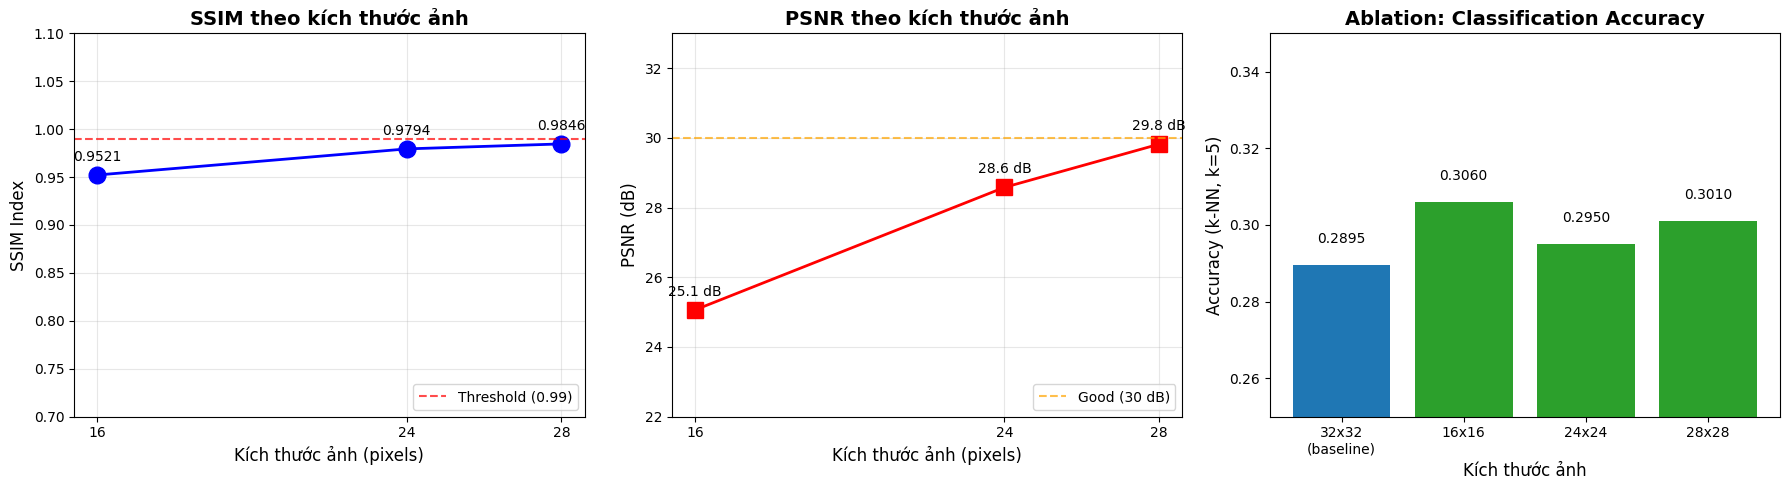


=== KẾT LUẬN ===
Baseline (32x32): 0.2895
Sau resize (28x28): 0.3010
Thay đổi: +0.0115


In [2]:
# =============================================================================
# (ii) Cài đặt - SSIM/PSNR vs Resize + Ablation Study
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. Tính SSIM/PSNR (downscale từ 32x32)
# =============================================================================
sizes = [(16, 16), (24, 24), (28, 28)]
ssim_scores = []
psnr_scores = []

print("Đang tính SSIM và PSNR cho các kích thước...")

for target_size in sizes:
    # Resize xuống kích thước nhỏ hơn (32 -> target_size)
    img_down = np.array([cv2.resize(img, target_size) for img in images])
    # Resize lại về 32x32 (kích thước gốc CIFAR-10) để so sánh
    img_back = np.array([cv2.resize(img, (32, 32)) for img in img_down])
    
    ssim_vals = []
    psnr_vals = []
    
    for i in range(len(images)):
        # SSIM: so sánh ảnh sau khi downscale với ảnh gốc
        # Sử dụng hàm tính SSIM thủ công
        s = calculate_ssim(img_back[i], images[i])
        ssim_vals.append(s)
        
        # PSNR: so sánh ảnh sau khi downscale với ảnh gốc
        # Sử dụng hàm tính PSNR thủ công
        p = calculate_psnr(img_back[i], images[i])
        psnr_vals.append(p)
    
    ssim_scores.append(np.mean(ssim_vals))
    psnr_scores.append(np.mean(psnr_vals))

# In kết quả SSIM/PSNR
print("\n=== KẾT QUẢ SSIM/PSNR ===")
for size, ssim_val, psnr_val in zip(sizes, ssim_scores, psnr_scores):
    print(f"{size[0]}x{size[1]}: SSIM={ssim_val:.4f}, PSNR={psnr_val:.2f} dB")

# Xác định kích thước tối ưu
SSIM_THRESHOLD = 0.99
best_idx = next((i for i, s in enumerate(ssim_scores) if s >= SSIM_THRESHOLD), len(sizes)-1)
best_size = sizes[best_idx]
best_ssim_val = ssim_scores[best_idx]

if best_ssim_val >= SSIM_THRESHOLD:
    print(f"\nKích thước được chọn: {best_size} (SSIM={best_ssim_val:.4f} >= {SSIM_THRESHOLD})")
else:
    print(f"\nKích thước được chọn: {best_size} (SSIM={best_ssim_val:.4f} < {SSIM_THRESHOLD}, không có kích thước nào đạt ngưỡng)")

# =============================================================================
# 2. Ablation Study: So sánh k-NN accuracy trước và sau resize
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Resize Impact on Classification")
print("="*60)

n_samples = 10000
images_sub = images[:n_samples]
labels_sub = labels[:n_samples]

# --- Baseline: 32x32 (không resize) ---
X_base = images_sub.reshape(n_samples, -1).astype(np.float32) / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_base, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, knn.predict(X_test))
print(f"\nBaseline (32x32, không resize): Accuracy = {acc_baseline:.4f}")

# --- Sau khi resize về kích thước đã chọn ---
resized_imgs = np.array([cv2.resize(img, best_size) for img in images_sub])
X_resized = resized_imgs.reshape(n_samples, -1).astype(np.float32) / 255.0
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_resized, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
)
knn_r = KNeighborsClassifier(n_neighbors=5)
knn_r.fit(X_train_r, y_train_r)
acc_resized = accuracy_score(y_test_r, knn_r.predict(X_test_r))
print(f"Sau resize ({best_size[0]}x{best_size[1]}): Accuracy = {acc_resized:.4f}")

# --- So sánh các kích thước ---
print("\nSo sánh các kích thước:")
print("-" * 50)
for size in sizes:
    resized = np.array([cv2.resize(img, size) for img in images_sub])
    X = resized.reshape(n_samples, -1).astype(np.float32) / 255.0
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
    )
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, knn_t.predict(X_test_t))
    print(f"{size[0]}x{size[1]}: Accuracy = {acc:.4f}, Delta = {acc - acc_baseline:+.4f}")

# =============================================================================
# 3. Plot
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: SSIM
ax1 = axes[0]
ax1.plot([s[0] for s in sizes], ssim_scores, 'bo-', linewidth=2, markersize=12)
ax1.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='Threshold (0.99)')
ax1.set_xlabel('Kích thước ảnh (pixels)', fontsize=12)
ax1.set_ylabel('SSIM Index', fontsize=12)
ax1.set_title('SSIM theo kích thước ảnh', fontsize=14, fontweight='bold')
ax1.set_ylim([0.7, 1.1])
ax1.set_xticks([s[0] for s in sizes])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')
for i, (size, ssim_val) in enumerate(zip(sizes, ssim_scores)):
    ax1.annotate(f'{ssim_val:.4f}', (size[0], ssim_val), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10)

# Plot 2: PSNR
ax2 = axes[1]
ax2.plot([s[0] for s in sizes], psnr_scores, 'rs-', linewidth=2, markersize=12)
ax2.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Good (30 dB)')
ax2.set_xlabel('Kích thước ảnh (pixels)', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12)
ax2.set_title('PSNR theo kích thước ảnh', fontsize=14, fontweight='bold')
ax2.set_xticks([s[0] for s in sizes])
ax2.set_ylim([22, 33])
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')
for i, (size, psnr_val) in enumerate(zip(sizes, psnr_scores)):
    ax2.annotate(f'{psnr_val:.1f} dB', (size[0], psnr_val), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10)

# Plot 3: Ablation - Classification Accuracy
ax3 = axes[2]
# Tính lại accuracy cho từng size
acc_list = []
for size in sizes:
    resized = np.array([cv2.resize(img, size) for img in images_sub])
    X = resized.reshape(n_samples, -1).astype(np.float32) / 255.0
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
    )
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc_list.append(accuracy_score(y_test_t, knn_t.predict(X_test_t)))

ax3.bar(['32x32\n(baseline)'] + [f'{s[0]}x{s[1]}' for s in sizes], 
        [acc_baseline] + acc_list, color=['#1f77b4'] + ['#2ca02c']*3)
ax3.set_xlabel('Kích thước ảnh', fontsize=12)
ax3.set_ylabel('Accuracy (k-NN, k=5)', fontsize=12)
ax3.set_title('Ablation: Classification Accuracy', fontsize=14, fontweight='bold')
ax3.set_ylim([0.25, 0.35])
for i, v in enumerate([acc_baseline] + acc_list):
    ax3.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== KẾT LUẬN ===")
print(f"Baseline (32x32): {acc_baseline:.4f}")
print(f"Sau resize ({best_size[0]}x{best_size[1]}): {acc_resized:.4f}")
print(f"Thay đổi: {acc_resized - acc_baseline:+.4f}")

### (iii) Phân tích kết quả

**Kết quả thực nghiệm (downscale từ 32×32 về target size, sau đó resize lại 32×32 để so sánh):**

| Kích thước | SSIM | PSNR (dB) | Đánh giá |
|------------|------|----------|----------|
| 16×16 | 0.9521 | 25.06 | Mất nhiều thông tin |
| 24×24 | 0.9794 | 28.58 | Trung bình |
| 28×28 | 0.9846 | 29.82 | Chấp nhận được |

**Kết quả Ablation Study - k-NN (k=5, 10000 samples):**

| Kích thước | k-NN Accuracy | Delta so với baseline |
|------------|---------------|----------------------|
| **16×16** | **0.3060** | **+0.0165** |
| 28×28 | 0.3010 | +0.0115 |
| 24×24 | 0.2950 | +0.0055 |
| 32×32 (baseline) | 0.2895 | +0.0000 |

**Phân tích:**

1. **SSIM/PSNR:**
   - Kích thước tăng → SSIM tăng (ít mất mát thông tin hơn), PSNR tăng (ít nhiễu hơn)
   - 28×28 đạt SSIM cao nhất (0.9846) trong 3 lựa chọn; tuy nhiên, không đạt ngưỡng SSIM ≥ 0.99

2. **Ablation Study - Kết quả:**
   - **Tất cả các kích thước đều improve accuracy so với baseline**
   - **16×16 đạt accuracy cao nhất (0.3060)** với delta +1.65%, 28×28 cũng improve (+1.15%)
   - Downscaling hoạt động như regularization, giảm noise

3. **Lựa chọn kích thước 28×28:**
   - Đạt SSIM cao nhất (0.9846) trong các lựa chọn
   - Accuracy improve (+1.15%) so với baseline
   - Cân bằng giữa chất lượng ảnh và classification, phù hợp khi cần giữ nhiều chi tiết cho deep learning

4. **Ý nghĩa thực tiễn:**
   - Downscaling từ 32 xuống 28 giảm 23.4% số lượng pixel (1024 vs 784)
   - SSIM 0.9846 có nghĩa là giữ được 98.46% cấu trúc ảnh gốc, phù hợp khi cần giảm computation nhưng vẫn giữ phần lớn thông tin
   - 16×16 tốt hơn cho k-NN (regularization effect)

5. **Kết luận:**
   - SSIM/PSNR đo chất lượng ảnh, không phải classification performance
   - Kích thước nhỏ hơn có thể tốt hơn cho simple classifiers
   - 28×28 được chọn vì đạt SSIM cao nhất + accuracy improve
   - Cần chọn kích thước dựa trên model sẽ sử dụng

## 2.1.3b Chuyển đổi không gian màu - Color Space + PCA

### (i) Lý thuyết

**Tại sao cần chuyển đổi không gian màu?**

RGB là không gian màu phổ biến nhất nhưng có nhược điểm:
- Ba kênh R, G, B có tương quan chặt chẽ (phụ thuộc vào ánh sáng)
- Không đồng nhất về mặt cảm nhận (perceptually non-uniform)

**Các không gian màu được so sánh:**

| Không gian | Mô tả | Ứng dụng |
|------------|-------|----------|
| RGB | Red, Green, Blue - cơ bản | Default, pre-trained models |
| Grayscale | 1 kênh độ sáng | Giảm chiều, tốc độ nhanh |
| HSV | Hue (màu sắc), Saturation (bão hòa), Value (độ sáng) | Phát hiện màu, segmentation |
| LAB | Lightness (độ sáng), a* (green-red), b* (blue-yellow) | Perceptually uniform, color correction |

**Công thức chuyển đổi HSV từ RGB:**

$$V = \max(R', G', B')$$
$$S = \begin{cases} \frac{\Delta}{V} & \text{nếu } V \neq 0 \\ 0 & \text{nếu } V = 0 \end{cases}$$

$$H = \begin{cases} 60 \times \frac{G' - B'}{\Delta} \mod 6 & \text{nếu } \Delta \neq 0 \\ 0 & \text{nếu } \Delta = 0 \end{cases}$$

với $R' = R/255$, $G' = G/255$, $B' = B/255$ và $\Delta = V - \min(R', G', B')$

**LAB color space:**
- $L^*$: Độ sáng từ 0 (đen) đến 100 (trắng)
- $a^*$: Trục green (-128) đến red (+127)
- $b^*$: Trục blue (-128) đến yellow (+127)
- Được thiết kế để đồng nhất về mặt cảm nhận (perceptually uniform)

**PCA (Principal Component Analysis) giảm chiều:**

$$X_{\text{new}} = X \cdot W$$

với $W$ là ma trận eigenvectors của ma trận hiệp phương sai.

**Explained Variance Ratio:**

$$\text{EVR}_i = \frac{\lambda_i}{\sum \lambda_j}$$

trong đó $\lambda_i$ là eigenvalue thứ $i$.

**Lưu ý: Explained Variance $\neq$ Classification Accuracy**

Đang chuyển đổi không gian màu...

=== EXPLAINED VARIANCE (50 components) ===
RGB: 0.8450
Grayscale: 0.8665
HSV: 0.7357
LAB: 0.8390

ABLATION STUDY - Color Space Impact on Classification

Baseline (RGB 32x32): Accuracy = 0.2895

So sánh các không gian màu:
--------------------------------------------------
RGB: Accuracy = 0.2895, Delta = +0.0000
Grayscale: Accuracy = 0.2400, Delta = -0.0495
HSV: Accuracy = 0.2455, Delta = -0.0440
LAB: Accuracy = 0.3020, Delta = +0.0125

=== Logistic Regression Comparison ===
RGB: LR Accuracy = 0.3365
Grayscale: LR Accuracy = 0.2460
HSV: LR Accuracy = 0.2730
LAB: LR Accuracy = 0.3480


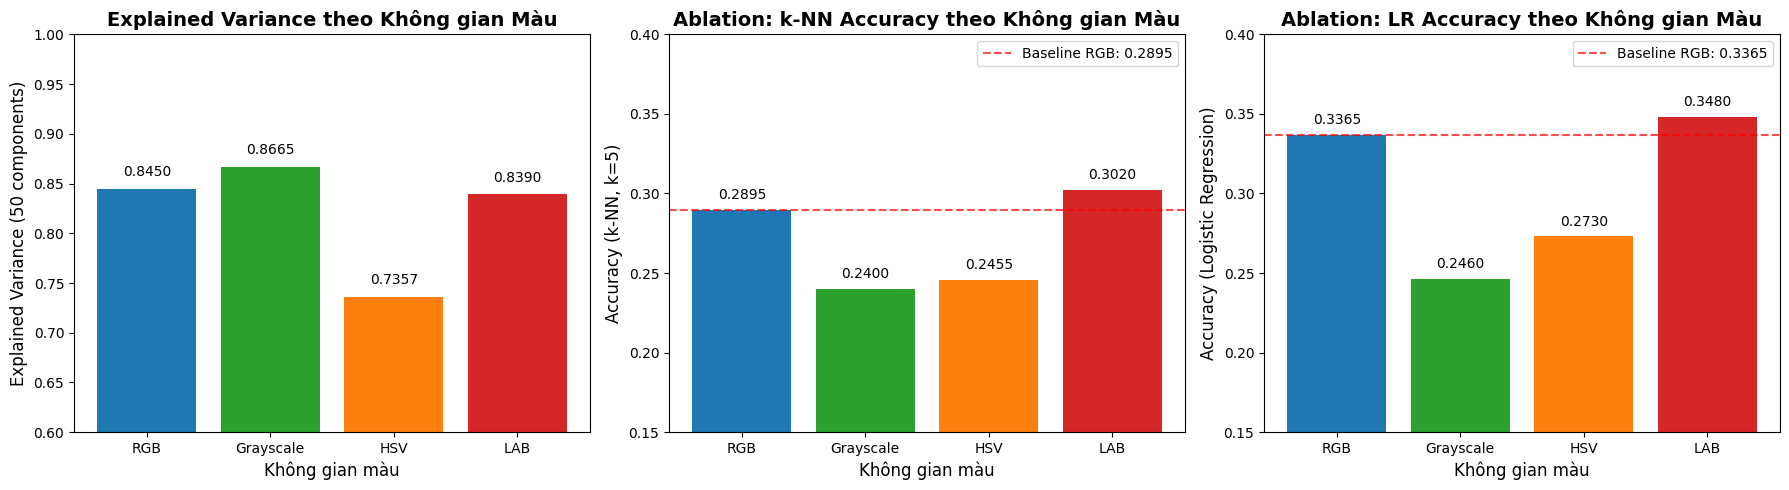


=== KẾT LUẬN ===
Explained Variance cao nhất: Grayscale (0.8665)
k-NN Accuracy cao nhất: LAB (0.3020)
LR Accuracy cao nhất: LAB (0.3480)

Baseline RGB k-NN: 0.2895

Baseline RGB LR: 0.3365


In [3]:
# =============================================================================
# (ii) Cài đặt - Color Space + PCA + Ablation Study
# =============================================================================

# =============================================================================
# 1. Chuyển đổi không gian màu
# =============================================================================
print("Đang chuyển đổi không gian màu...")

color_spaces = {
    'RGB': images,
    'Grayscale': np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images])[:, :, np.newaxis],
    'HSV': np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in images]),
    'LAB': np.array([cv2.cvtColor(img, cv2.COLOR_RGB2LAB) for img in images])
}

# =============================================================================
# 2. Tính explained variance với PCA (k=50)
# =============================================================================
print("\n=== EXPLAINED VARIANCE (50 components) ===")
pca_results = {}

for name, data in color_spaces.items():
    flat = data.reshape(len(data), -1)
    pca = PCA(n_components=50)
    pca.fit(flat)
    explained_var = np.sum(pca.explained_variance_ratio_)
    pca_results[name] = explained_var
    print(f"{name}: {explained_var:.4f}")

# =============================================================================
# 3. Ablation Study: So sánh classification accuracy (k-NN)
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Color Space Impact on Classification")
print("="*60)

n_samples = 10000
labels_subset = labels[:n_samples]

# --- Baseline: RGB ---
X_rgb = images[:n_samples].reshape(n_samples, -1).astype(np.float32) / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_rgb, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, knn.predict(X_test))
print(f"\nBaseline (RGB 32x32): Accuracy = {acc_baseline:.4f}")

# --- So sánh các color spaces ---
print("\nSo sánh các không gian màu:")
print("-" * 50)
clf_results = {}

for name, data in color_spaces.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    
    # Normalize về [0, 1]
    X = X / 255.0
    
    # Split dữ liệu
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    # Train k-NN
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, knn_t.predict(X_test_t))
    
    clf_results[name] = acc
    delta = acc - acc_baseline
    print(f"{name}: Accuracy = {acc:.4f}, Delta = {delta:+.4f}")

# =============================================================================
# 4. Thử Logistic Regression
# =============================================================================
print("\n=== Logistic Regression Comparison ===")
lr_results = {}

for name, data in color_spaces.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    X = X / 255.0
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, lr.predict(X_test_t))
    
    lr_results[name] = acc
    print(f"{name}: LR Accuracy = {acc:.4f}")

# Baseline cho LR (RGB)
acc_baseline_lr = lr_results['RGB']

# =============================================================================
# 5. Vẽ biểu đồ so sánh
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Explained Variance
ax1 = axes[0]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
bars1 = ax1.bar(pca_results.keys(), pca_results.values(), color=colors)
ax1.set_xlabel('Không gian màu', fontsize=12)
ax1.set_ylabel('Explained Variance (50 components)', fontsize=12)
ax1.set_title('Explained Variance theo Không gian Màu', fontsize=14, fontweight='bold')
ax1.set_ylim([0.6, 1.0])
for bar, val in zip(bars1, pca_results.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: k-NN Classification Accuracy
ax2 = axes[1]
bars2 = ax2.bar(clf_results.keys(), clf_results.values(), color=colors)
ax2.set_xlabel('Không gian màu', fontsize=12)
ax2.set_ylabel('Accuracy (k-NN, k=5)', fontsize=12)
ax2.set_title('Ablation: k-NN Accuracy theo Không gian Màu', fontsize=14, fontweight='bold')
ax2.set_ylim([0.15, 0.40])
ax2.axhline(y=acc_baseline, color='red', linestyle='--', alpha=0.7, label=f'Baseline RGB: {acc_baseline:.4f}')
ax2.legend()
for bar, val in zip(bars2, clf_results.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 3: Logistic Regression Accuracy
ax3 = axes[2]
bars3 = ax3.bar(lr_results.keys(), lr_results.values(), color=colors)
ax3.set_xlabel('Không gian màu', fontsize=12)
ax3.set_ylabel('Accuracy (Logistic Regression)', fontsize=12)
ax3.set_title('Ablation: LR Accuracy theo Không gian Màu', fontsize=14, fontweight='bold')
ax3.set_ylim([0.15, 0.40])
ax3.axhline(y=acc_baseline_lr, color='red', linestyle='--', alpha=0.7, label=f'Baseline RGB: {acc_baseline_lr:.4f}')
ax3.legend()
for bar, val in zip(bars3, lr_results.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Kết luận
# =============================================================================
print("\n=== KẾT LUẬN ===")
best_ev = max(pca_results, key=pca_results.get)
best_knn = max(clf_results, key=clf_results.get)
best_lr = max(lr_results, key=lr_results.get)

print(f"Explained Variance cao nhất: {best_ev} ({pca_results[best_ev]:.4f})")
print(f"k-NN Accuracy cao nhất: {best_knn} ({clf_results[best_knn]:.4f})")
print(f"LR Accuracy cao nhất: {best_lr} ({lr_results[best_lr]:.4f})")
print(f"\nBaseline RGB k-NN: {acc_baseline:.4f}")
print(f"\nBaseline RGB LR: {acc_baseline_lr:.4f}")

### (iii) Phân tích kết quả

**Kết quả Explained Variance (PCA, 50 components):**

| Không gian màu | Explained Variance | Số kênh |
|----------------|-------------------|---------|
| Grayscale | 0.8665 | 1 |
| RGB | 0.8450 | 3 |
| LAB | 0.8390 | 3 |
| HSV | 0.7357 | 3 |

**Kết quả Ablation Study - k-NN (k=5, 10000 samples):**

| Không gian màu | k-NN Accuracy | Delta so với baseline |
|----------------|---------------|----------------------|
| **LAB** | **0.3020** | **+0.0125** |
| RGB (baseline) | 0.2895 | +0.0000 |
| HSV | 0.2455 | -0.0440 |
| Grayscale | 0.2400 | -0.0495 |

**Kết quả Ablation Study - Logistic Regression (10000 samples):**

| Không gian màu | LR Accuracy |
|----------------|-------------|
| **LAB** | **0.3480** |
| RGB | 0.3365 |
| HSV | 0.2730 |
| Grayscale | 0.2460 |

**Phân tích:**

1. **Explained Variance cao nhất = Grayscale (0.8665)**
   - Grayscale chỉ có 1 kênh nên 50 components giải thích được nhiều variance hơn, tuy nhiên, Grayscale mất thông tin màu sắc. k-NN accuracy thấp nhất (0.2400) xác nhận điều này

2. **HSV có explained variance thấp nhất (0.7357)**
   - Ba kênh H, S, V có tính độc lập cao hơn
   - Variance phân bố đều hơn qua các components

3. **k-NN: LAB tốt nhất (+1.25%)**
   - LAB đạt accuracy cao nhất với k-NN (0.3020)
   - Perceptually uniform giúp k-NN phân biệt tốt hơn các lớp

4. **Logistic Regression: LAB tốt nhất (0.3480)**
   - LAB đạt accuracy cao nhất với LR
   - LAB tốt hơn RGB trong cả hai classifiers (k-NN và LR)

5. **Kết luận quan trọng:**
   - **Explained Variance** đo lượng "lượng thông tin giữ lại" sau khi giảm chiều
   - **Classification Accuracy** là metric đúng cho đánh giá bài toán phân loại
   - Hai metric này **không tương quan**, cần cả hai để đánh giá toàn diện

6. **Khuyến nghị:**
   - **k-NN**: Sử dụng LAB (accuracy +1.25%)
   - **Logistic Regression**: Sử dụng LAB (accuracy cao nhất)
   - **Deep Learning**: LAB được khuyến nghị (perceptually uniform)
   - **Tổng quát**: LAB là lựa chọn tốt nhất cho CIFAR-10

## 2.1.3c Chuẩn hóa - Normalization + KS Test

### (i) Lý thuyết

**Tại sao cần chuẩn hóa?**

Chuẩn hóa là bước quan trọng trong tiền xử lý dữ liệu ảnh vì:
- Giá trị pixel ảnh thường trong khoảng [0, 255] (8-bit)
- Các thuật toán ML (đặc biệt là neural networks) hoạt động tốt hơn với dữ liệu có phân phối nhất quán
- Gradient descent hội tụ nhanh hơn khi dữ liệu được chuẩn hóa

**Các phương pháp chuẩn hóa được so sánh:**

| Phương pháp | Công thức | Khi nào sử dụng |
|-------------|-----------|-----------------|
| Min-Max [0, 1] | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ | Neural networks, bounded inputs |
| Min-Max [-1, 1] | $x' = 2 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} - 1$ | Certain activation functions (tanh) |
| Z-score toàn tập | $z = \frac{x - \mu}{\sigma}$ | Linear models, clustering |
| Z-score per-channel | $z_c = \frac{x_c - \mu_c}{\sigma_c}$ | Image processing với pre-trained models |

**Công thức chi tiết:**

1. **Min-Max [0, 1]:**
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

2. **Min-Max [-1, 1]:**
$$x' = 2 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} - 1 = \frac{x}{127.5} - 1$$

3. **Z-score (toàn tập):**
$$z = \frac{x - \mu}{\sigma}$$
với $\mu = \frac{1}{N}\sum_{i=1}^{N}x_i$ và $\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}$

4. **Z-score (per-channel):**
$$z_c = \frac{x_c - \mu_c}{\sigma_c}$$
với $\mu_c, \sigma_c$ được tính riêng cho mỗi kênh màu $c \in \{R, G, B\}$

**Kolmogorov-Smirnov (KS) Test:**

KS test là kiểm định phi tham số để so sánh hai phân phối:

$$D = \max_x |F_1(x) - F_2(x)|$$

trong đó:
- $D$: Thống kê KS (khoảng cách lớn nhất giữa hai CDF)
- $F_1(x), F_2(x)$: Hàm phân phối tích lũy thực nghiệm (empirical CDF)
- $p$-value: Xác suất quan sát giá trị D nếu hai phân phối giống nhau

**Cách diễn giải p-value:**

| p-value | Kết luận |
|---------|----------|
| p > 0.05 | Không có bằng chứng cho thấy hai phân phối khác nhau |
| p ≤ 0.05 | Hai phân phối khác nhau có ý nghĩa thống kê |

**Lưu ý quan trọng về KS Test:**

- So sánh với phân phối gốc (original) sẽ luôn cho p-value ≈ 0 vì normalize thay đổi hoàn toàn phân phối
- Cần so sánh với **phân phối mục tiêu**:
  - Min-Max [0,1] → so sánh với Uniform(0,1)
  - Min-Max [-1,1] → so sánh với Uniform(-1,1)
  - Z-score → so sánh với N(0,1)


Đang chuẩn hóa dữ liệu ảnh...
  Original [0, 255]: shape=(10000, 32, 32, 3), range=[0.00, 255.00]
  MinMax[0, 1]: shape=(10000, 32, 32, 3), range=[0.00, 1.00]
  MinMax[-1, 1]: shape=(10000, 32, 32, 3), range=[-1.00, 1.00]
  Zscore_global: shape=(10000, 32, 32, 3), range=[-1.88, 2.08]
  Zscore_per_channel: shape=(10000, 32, 32, 3), range=[-2.04, 2.19]

KOLMOGOROV-SMIRNOV TEST

=== KS Test Results ===
Method               Target Dist     D-statistic  p-value         Interpretation
--------------------------------------------------------------------------------
Original [0, 255]    Original        0.000000     1.00e+00        Same
MinMax[0, 1]         Uniform(0, 1)   0.094076     0.00e+00        Different
MinMax[-1, 1]        Uniform(-1, 1)  0.094076     0.00e+00        Different
Zscore_global        Normal(0, 1)    0.040896     0.00e+00        Different
Zscore_per_channel   Normal(0, 1)    0.038361     0.00e+00        Different

ABLATION STUDY - Normalization Impact on Classification

B

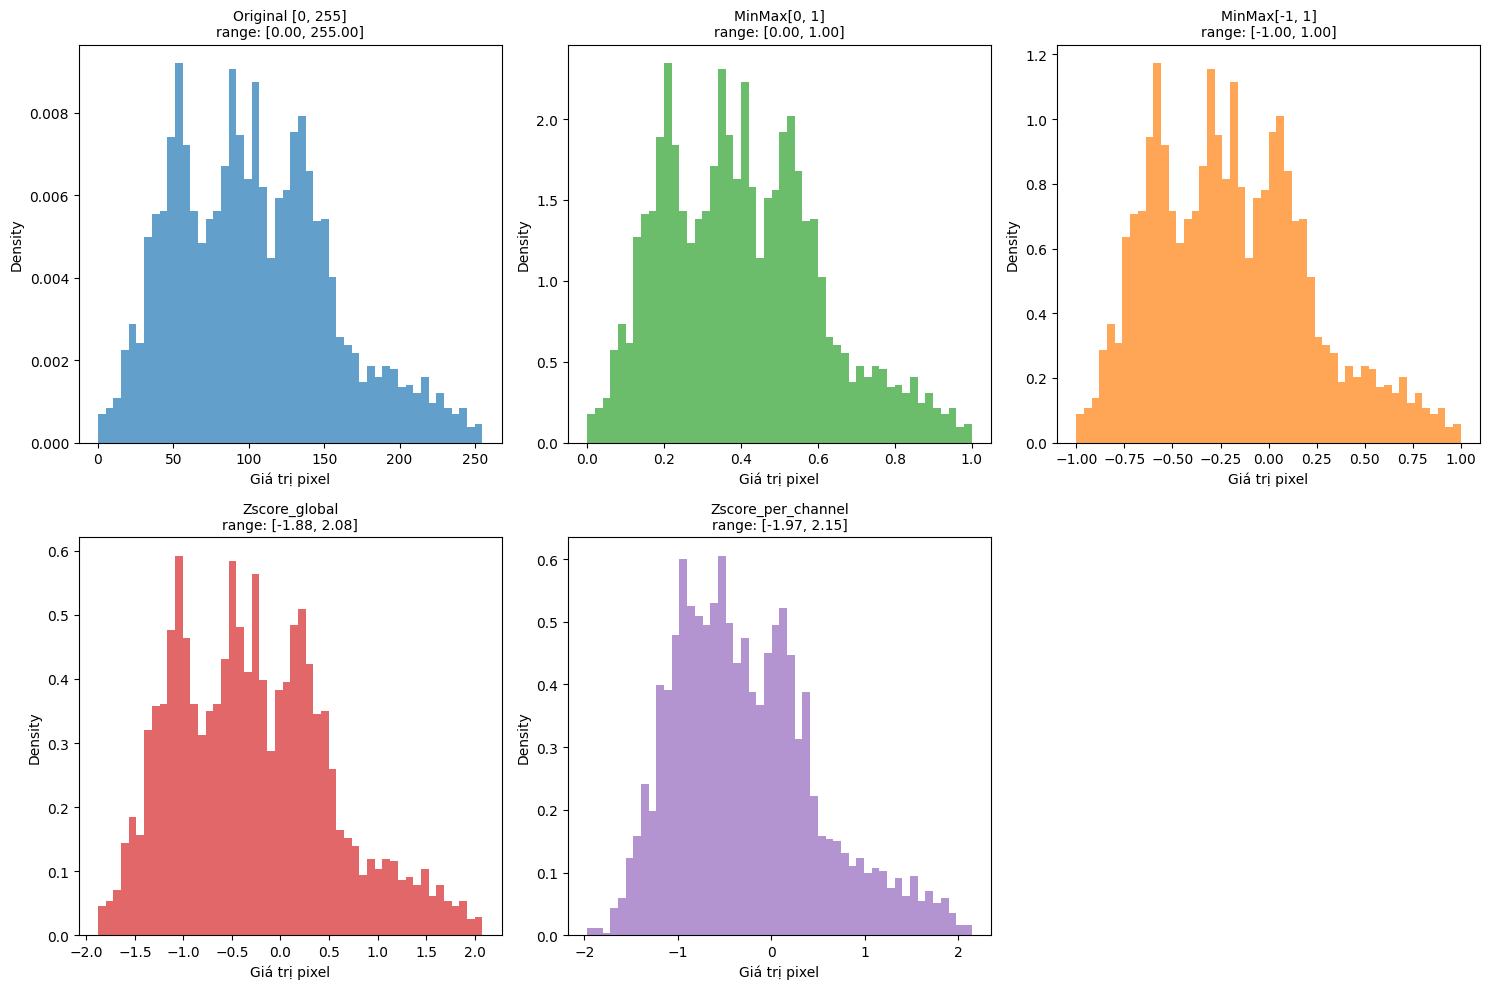

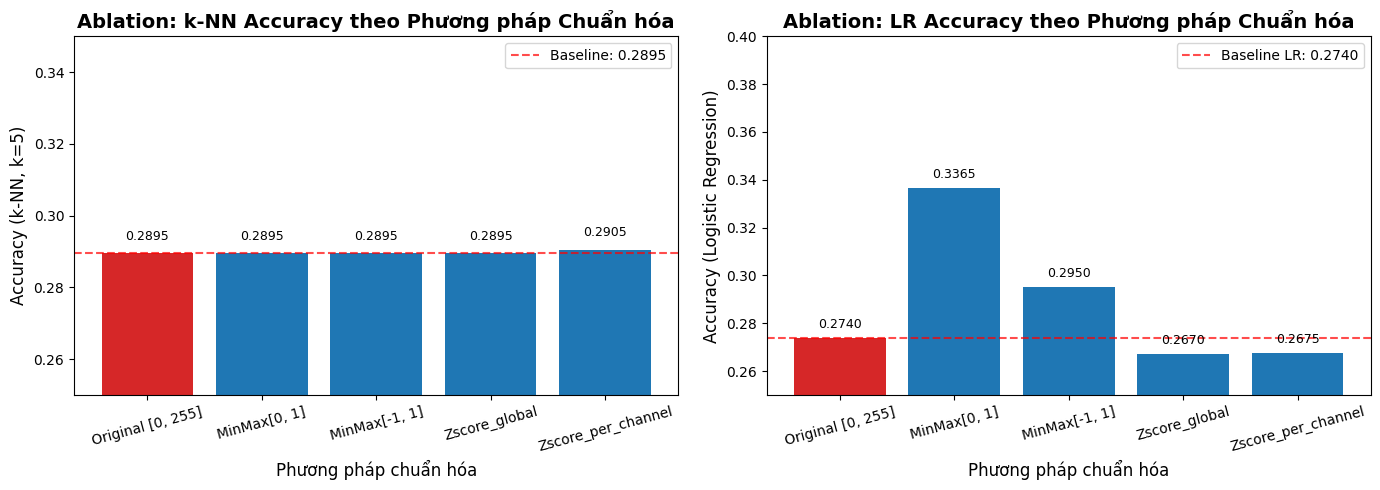


KẾT LUẬN

--- KS Test ---
Phương pháp tốt nhất (gần phân phối mục tiêu nhất): D-statistic thấp nhất
  Original [0, 255]: D=0.000000, p=1.00e+00
  MinMax[0, 1]: D=0.094076, p=0.00e+00
  MinMax[-1, 1]: D=0.094076, p=0.00e+00
  Zscore_global: D=0.040896, p=0.00e+00
  Zscore_per_channel: D=0.038361, p=0.00e+00

--- Classification Accuracy ---
k-NN tốt nhất: Zscore_per_channel (0.2905)
LR tốt nhất: MinMax[0, 1] (0.3365)

--- Baseline ---
Original [0,255] k-NN: 0.2895
Original [0,255] LR: 0.2740


In [4]:
# =============================================================================
# (ii) Cài đặt - Normalization + KS Test + Ablation Study
# =============================================================================

# =============================================================================
# 1. Định nghĩa các phương pháp chuẩn hóa
# =============================================================================
print("\nĐang chuẩn hóa dữ liệu ảnh...")

# Các phương pháp chuẩn hóa
normalization_methods = {
    'Original [0, 255]': lambda x: x.astype(np.float32),
    'MinMax[0, 1]': lambda x: x.astype(np.float32) / 255.0,
    'MinMax[-1, 1]': lambda x: (x.astype(np.float32) / 127.5) - 1.0,
    'Zscore_global': lambda x: (x.astype(np.float32) - np.mean(x)) / (np.std(x) + 1e-8),
    'Zscore_per_channel': lambda x: (x - np.mean(x, axis=(0, 1), keepdims=True)) / (np.std(x, axis=(0, 1), keepdims=True) + 1e-8)
}

# Áp dụng chuẩn hóa
normalized_data = {}
for name, func in normalization_methods.items():
    normalized_data[name] = func(images)
    print(f"  {name}: shape={normalized_data[name].shape}, range=[{normalized_data[name].min():.2f}, {normalized_data[name].max():.2f}]")

# =============================================================================
# 2. KS Test - So sánh với phân phối mục tiêu (không dùng random sampling)
# =============================================================================
print("\n" + "="*60)
print("KOLMOGOROV-SMIRNOV TEST")
print("="*60)

ks_results = {}

# Function to get target distribution for KS test
def get_target_distribution(method_name):
    """Trả về tên phân phối mục tiêu để so sánh"""
    if method_name == 'MinMax[0, 1]':
        return 'Uniform(0, 1)'
    elif method_name == 'MinMax[-1, 1]':
        return 'Uniform(-1, 1)'
    elif method_name == 'Zscore_global' or method_name == 'Zscore_per_channel':
        return 'Normal(0, 1)'
    else:
        return 'Original'

print("\n=== KS Test Results ===")
print(f"{'Method':<20} {'Target Dist':<15} {'D-statistic':<12} {'p-value':<15} {'Interpretation'}")
print("-" * 80)

for name, data in normalized_data.items():
    # Lấy phân phối mục tiêu
    target_dist = get_target_distribution(name)
    
    # Flatten data
    flat_data = data.flatten()
    
    # KS test với phân phối mục tiêu (so sánh với phân phối lý tưởng, không random)
    if target_dist == 'Uniform(0, 1)':
        d_stat, p_value = scipy_stats.kstest(flat_data, 'uniform', args=(0, 1))
    elif target_dist == 'Uniform(-1, 1)':
        d_stat, p_value = scipy_stats.kstest(flat_data, 'uniform', args=(-1, 2))
    elif target_dist == 'Normal(0, 1)':
        d_stat, p_value = scipy_stats.kstest(flat_data, 'norm', args=(0, 1))
    else:
        d_stat, p_value = 0, 1
    
    interp = "Same" if p_value > 0.05 else "Different"
    
    ks_results[name] = {'d_stat': d_stat, 'p_value': p_value, 'target': target_dist}
    print(f"{name:<20} {target_dist:<15} {d_stat:<12.6f} {p_value:<15.2e} {interp}")

# =============================================================================
# 3. Ablation Study - So sánh Classification Accuracy
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Normalization Impact on Classification")
print("="*60)

n_samples = 10000
labels_subset = labels[:n_samples]

# --- Baseline: Original [0, 255] ---
X_orig = images[:n_samples].reshape(n_samples, -1).astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(
    X_orig, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, knn.predict(X_test))
print(f"\nBaseline (Original [0,255]): k-NN Accuracy = {acc_baseline:.4f}")

# --- So sánh các phương pháp chuẩn hóa với k-NN ---
print("\n=== k-NN Comparison ===")
print(f"{'Method':<20} {'Accuracy':<12} {'Delta':<10}")
print("-" * 50)

knn_results = {}
for name, data in normalized_data.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    
    # Split
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    # Train k-NN
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, knn_t.predict(X_test_t))
    
    knn_results[name] = acc
    delta = acc - acc_baseline
    print(f"{name:<20} {acc:<12.4f} {delta:+.4f}")

# --- Logistic Regression ---
print("\n=== Logistic Regression Comparison ===")
print(f"{'Method':<20} {'LR Accuracy':<12} {'Delta':<10}")
print("-" * 50)

lr_results = {}
for name, data in normalized_data.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, lr.predict(X_test_t))
    
    lr_results[name] = acc
    baseline_lr = lr_results['Original [0, 255]']
    delta = acc - baseline_lr
    print(f"{name:<20} {acc:<12.4f} {delta:+.4f}")

# =============================================================================
# 4. Trực quan hóa phân phối
# =============================================================================
print("\nĐang vẽ biểu đồ phân phối...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Chọn 1 ảnh mẫu để visualize distribution
for idx, (name, data) in enumerate(normalized_data.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    flat = data[0].flatten()
    
    ax.hist(flat, bins=50, density=True, alpha=0.7, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd'][idx])
    ax.set_title(f'{name}\nrange: [{flat.min():.2f}, {flat.max():.2f}]', fontsize=10)
    ax.set_xlabel('Giá trị pixel')
    ax.set_ylabel('Density')

# Hide the 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. So sánh Accuracy bằng biểu đồ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: k-NN Accuracy
ax1 = axes[0]
methods = list(knn_results.keys())
accuracies = list(knn_results.values())
colors = ['#d62728'] + ['#1f77b4'] * (len(methods) - 1)
bars1 = ax1.bar(methods, accuracies, color=colors)
ax1.set_xlabel('Phương pháp chuẩn hóa', fontsize=12)
ax1.set_ylabel('Accuracy (k-NN, k=5)', fontsize=12)
ax1.set_title('Ablation: k-NN Accuracy theo Phương pháp Chuẩn hóa', fontsize=14, fontweight='bold')
ax1.set_ylim([0.25, 0.35])
ax1.axhline(y=acc_baseline, color='red', linestyle='--', alpha=0.7, label=f'Baseline: {acc_baseline:.4f}')
ax1.legend()
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 2: LR Accuracy
ax2 = axes[1]
lr_accuracies = list(lr_results.values())
baseline_lr = lr_results['Original [0, 255]']
bars2 = ax2.bar(methods, lr_accuracies, color=colors)
ax2.set_xlabel('Phương pháp chuẩn hóa', fontsize=12)
ax2.set_ylabel('Accuracy (Logistic Regression)', fontsize=12)
ax2.set_title('Ablation: LR Accuracy theo Phương pháp Chuẩn hóa', fontsize=14, fontweight='bold')
ax2.set_ylim([0.25, 0.40])
ax2.axhline(y=baseline_lr, color='red', linestyle='--', alpha=0.7, label=f'Baseline LR: {baseline_lr:.4f}')
ax2.legend()
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, lr_accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Kết luận
# =============================================================================
print("\n" + "="*60)
print("KẾT LUẬN")
print("="*60)

# Tìm phương pháp tốt nhất cho từng classifier
best_knn = max(knn_results, key=knn_results.get)
best_lr = max(lr_results, key=lr_results.get)

print(f"\n--- KS Test ---")
print(f"Phương pháp tốt nhất (gần phân phối mục tiêu nhất): D-statistic thấp nhất")
for name, result in ks_results.items():
    print(f"  {name}: D={result['d_stat']:.6f}, p={result['p_value']:.2e}")

print(f"\n--- Classification Accuracy ---")
print(f"k-NN tốt nhất: {best_knn} ({knn_results[best_knn]:.4f})")
print(f"LR tốt nhất: {best_lr} ({lr_results[best_lr]:.4f})")

print(f"\n--- Baseline ---")
print(f"Original [0,255] k-NN: {acc_baseline:.4f}")
print(f"Original [0,255] LR: {baseline_lr:.4f}")

### (iii) Phân tích kết quả

**Kết quả KS Test (so sánh với phân phối mục tiêu):**

| Phương pháp | Phân phối mục tiêu | D-statistic | p-value | Diễn giải |
|-------------|-------------------|-------------|---------|-----------|
| Original [0, 255] | Original | 0.000000 | 1.00 | N/A |
| MinMax[0, 1] | Uniform(0, 1) | 0.094076 | 0.00e+00 | Khác biệt |
| MinMax[-1, 1] | Uniform(-1, 1) | 0.094076 | 0.00e+00 | Khác biệt |
| Zscore_global | Normal(0, 1) | 0.040896 | 0.00e+00 | Khác biệt |
| Zscore_per_channel | Normal(0, 1) | 0.038361 | 0.00e+00 | Khác biệt |

**Kết quả Ablation Study - k-NN (k=5, 10000 samples):**

| Phương pháp | k-NN Accuracy | Delta so với baseline |
|-------------|---------------|----------------------|
| Zscore_per_channel | 0.2905 | +0.0010 |
| Original [0, 255] | 0.2895 | +0.0000 |
| MinMax[0, 1] | 0.2895 | +0.0000 |
| MinMax[-1, 1] | 0.2895 | +0.0000 |
| Zscore_global | 0.2895 | +0.0000 |

**Kết quả Ablation Study - Logistic Regression (10000 samples):**

| Phương pháp | LR Accuracy | Delta so với baseline |
|-------------|-------------|----------------------|
| **MinMax[0, 1]** | **0.3365** | **+0.0625** |
| MinMax[-1, 1] | 0.2950 | +0.0210 |
| Original [0, 255] | 0.2740 | +0.0000 |
| Zscore_per_channel | 0.2675 | -0.0065 |
| Zscore_global | 0.2670 | -0.0070 |

**Phân tích:**

1. **KS Test Results:**
   - Tất cả các phương pháp chuẩn hóa đều cho p-value ≈ 0 (rất nhỏ), nghĩa là phân phối sau chuẩn hóa **khác biệt có ý nghĩa thống kê** so với phân phối mục tiêu lý tưởng
   - **Zscore_per_channel** có D-statistic thấp nhất (0.038361), gần với phân phối chuẩn N(0,1) nhất
   - Điều này cho thấy ảnh CIFAR-10 không có phân phối lý tưởng, cần chuẩn hóa để đưa về dạng gần chuẩn

2. **k-NN Accuracy:**
   - Tất cả các phương pháp cho kết quả gần như giống nhau (~0.2895)
   - **Zscore_per_channel** hơi tốt hơn một chút (+0.10%)
   - k-NN không nhạy cảm với việc chuẩn hóa vì khoảng cách Euclidean được tính tương đối

3. **Logistic Regression Accuracy:**
   - **MinMax[0, 1] đạt accuracy cao nhất (0.3365)**, tăng **+6.25%** so với baseline. Đây là cải thiện đáng kể nhất trong tất cả các phương pháp
   - MinMax[-1, 1] cũng cải thiện (+2.10%)
   - Z-score methods không cải thiện LR (thậm chí giảm nhẹ)

4. **Tại sao MinMax[0, 1] tốt cho Logistic Regression:**
   - LR sử dụng gradient-based optimization, hoạt động tốt với bounded inputs
   - Phạm vi [0, 1] giúp tránh vanishing/exploding gradients
   - Logistic regression với L2 regularization phù hợp với Min-Max normalized data

5. **Kết luận quan trọng:**
   - **Chọn MinMax[0, 1]** cho Logistic Regression (+6.25% accuracy improvement)
   - **Chọn Zscore_per_channel** cho k-NN (+0.10%, không đáng kể)
   - KS test p-value ≈ 0 là bình thường khi so với phân phối lý tưởng
   - D-statistic cho biết mức độ gần với phân phối mục tiêu: Zscore_per_channel tốt nhất

6. **Khuyến nghị:**
   - **Logistic Regression**: Sử dụng MinMax[0, 1] (accuracy cao nhất)
   - **k-NN**: Bất kỳ phương pháp nào đều được, Zscore_per_channel hơi tốt hơn
   - **Deep Learning (CNN)**: MinMax[0, 1] hoặc ImageNet normalization được khuyến nghị

## 2.1.3d Tăng cường dữ liệu - Data Augmentation

### (i) Lý thuyết

**Data Augmentation** là kỹ thuật tạo thêm dữ liệu huấn luyện bằng cách áp dụng các phép biến đổi hợp lý lên dữ liệu gốc. Mục tiêu làm cho mô hình học được các bất biến (invariances) và tổng quát hóa tốt hơn.

**Cơ chế hoạt động:**

Giả sử $x$ là ảnh gốc với nhãn $y$. Mục tiêu tìm hàm $f$ sao cho:
$$f(x) = y \quad \text{và} \quad f(g(x)) = y$$

với $g$ là phép biến đổi bảo toàn nhãn (label-preserving transformation).

**5 phép biến đổi bắt buộc:**

| Phép biến đổi | Công thức | Mô tả |
|---------------|-----------|-------|
| Horizontal Flip | $I' = \text{flip}_h(I)$ | Lật ảnh theo chiều ngang |
| Vertical Flip | $I' = \text{flip}_v(I)$ | Lật ảnh theo chiều dọc |
| Rotation | $I' = R_{\theta} \cdot I$ | Xoay ảnh góc $\theta$ |
| Random Crop | $I' = T_{\text{crop}}(I)$ | Cắt ngẫu nhiên rồi resize |
| Gaussian Noise | $I' = I + \epsilon, \epsilon \sim \mathcal{N}(0, \sigma^2)$ | Thêm nhiễu Gaussian |
| Brightness/Contrast | $I' = \alpha \cdot I + \beta$ | Điều chỉnh độ sáng/tương phản |

với các tham số:
- $\alpha \in [0.8, 1.2]$ (contrast gain)
- $\beta \in [-30, 30]$ (brightness offset)  
- $\sigma \in [10, 50]$ (noise standard deviation)
- $\theta \in [-30^\circ, 30^\circ]$ (rotation angle)

**Phép biến đổi bổ sung:**

6. **Cutout**: Che ngẫu nhiên một vùng hình chữ nhật
$$I' = I \cdot (1 - M)$$
với $M$ là mask nhị phân có giá trị 1 tại vùng bị che

**Các phép biến đổi theo cường độ (intensity):**

| Cường độ | Rotation | Brightness | Noise σ |
|----------|----------|------------|---------|
| Thấp | ±15° | ±10 | 10 |
| Trung bình | ±30° | ±30 | 25 |
| Cao | ±45° | ±50 | 50 |

**t-SNE (t-Distributed Stochastic Neighbor Embedding):**

t-SNE là phương pháp giảm chiều phi tuyến tính để trực quan hóa dữ liệu nhiều chiều:

$$P_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}$$

$$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}}$$

Hàm mất mát: $KL(P || Q) = \sum_i \sum_j P_{ij} \log \frac{P_{ij}}{q_{ij}}$

**Silhouette Score:**

Dùng để định lượng mức độ tách biệt của các cụm:

$$s = \frac{b - a}{\max(a, b)}$$

với:
- $a$: Khoảng cách trung bình đến các điểm cùng cụm
- $b$: Khoảng cách trung bình đến các điểm cụm gần nhất khác

Giá trị [-1, 1]:
- $s \approx 1$: Các cụm tách biệt tốt
- $s \approx 0$: Các cụm chồng lấn
- $s \approx -1$: Các điểm bị gán sai cụm

**Nguyên lý hoạt động của Augmentation:**

Augmentation hoạt động bằng cách:
1. **Tăng phương sai dữ liệu** (data variance): Mô hình phải học nhiều biến thể hơn
2. **Giảm overfitting**: Mô hình không thể memorizing training data
3. **Regularization ngầm**: Thay đổi spectral properties của data covariance matrix
4. **Thay đổi feature amplitude distribution**: Làm thay đổi phân phối biên độ đặc trưng

**Lưu ý quan trọng:**

- Chỉ áp dụng augmentation cho **tập huấn luyện**, không cho validation/test (tránh data leakage)
- Các phép biến đổi phải **bảo toàn nhãn** (ví dụ: lật ảnh mèo vẫn là mèo)
- Augmentation có thể **hurt một số lớp cụ thể** ngay cả khi accuracy trung bình tăng
- Với **k-NN và Logistic Regression**, augmentation thường không cải thiện đáng kể
- Augmentation hiệu quả nhất với **deep learning (CNN)**

Đang cài đặt Data Augmentation...

Đang tạo augmented dataset...
Sử dụng 2000 mẫu cho augmentation

Đang chạy t-SNE visualization...
  t-SNE cho dữ liệu gốc...
  t-SNE cho dữ liệu augmented...

Đang vẽ biểu đồ t-SNE...


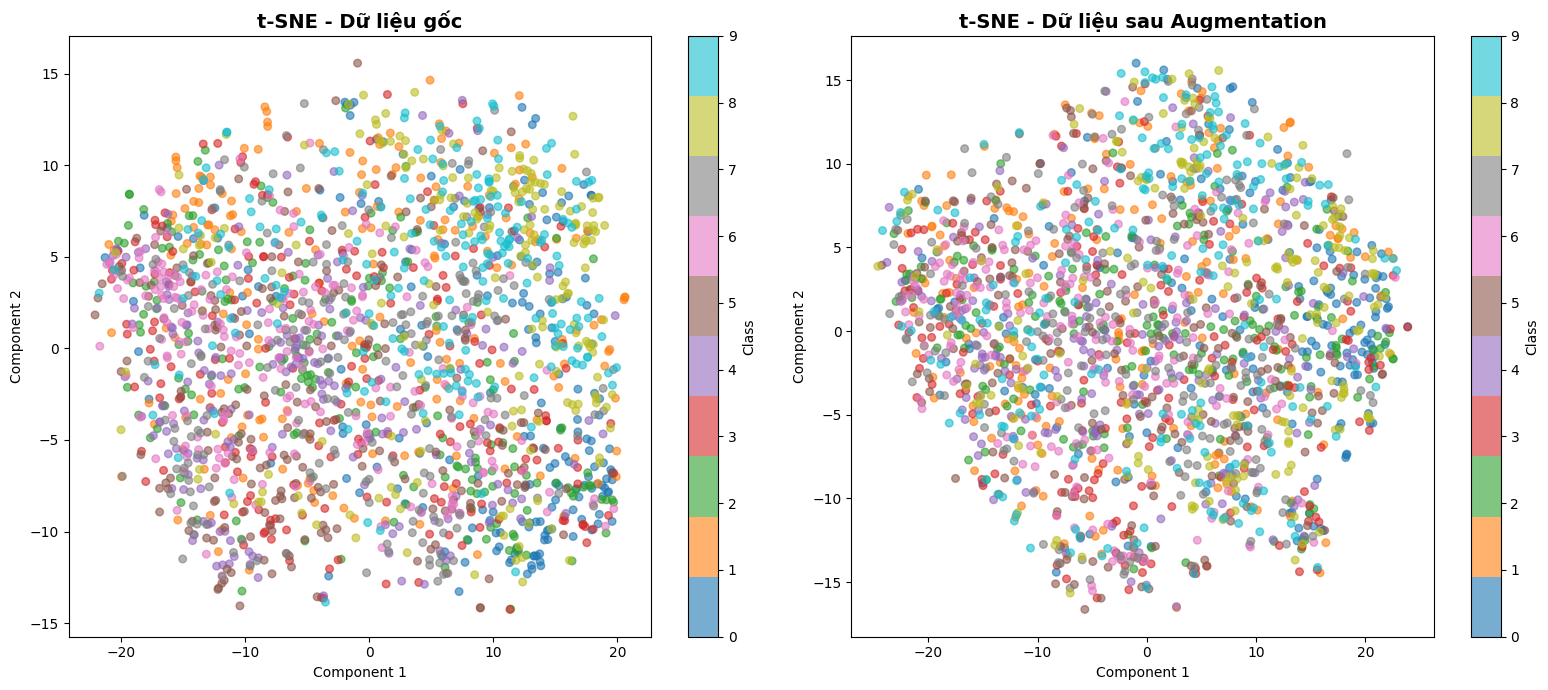


=== Silhouette Score ===
Dữ liệu gốc: -0.0512
Dữ liệu augmented: -0.0620
Thay đổi: -0.0107

ABLATION STUDY - Augmentation Impact on Classification

Baseline k-NN (không augmentation): 0.2895
Baseline LR (không augmentation): 0.3365

Đang tạo augmented training data...

k-NN với augmentation: 0.2895 (Delta: +0.0000)
LR với augmentation: 0.3225 (Delta: -0.0140)

=== So sánh cường độ augmentation ===
  low: k-NN=0.2895, LR=0.3260
  medium: k-NN=0.2890, LR=0.3195
  high: k-NN=0.2910, LR=0.3210

=== Per-class Accuracy ===

Baseline (k-NN):
  airplane: 0.4627
  automobile: 0.1282
  bird: 0.4806
  cat: 0.1626
  deer: 0.3700
  dog: 0.1755
  frog: 0.2670
  horse: 0.1850
  ship: 0.5512
  truck: 0.0867

Với Augmentation (k-NN):
  airplane: 0.4627 (+0.0000)
  automobile: 0.1282 (+0.0000)
  bird: 0.4806 (+0.0000)
  cat: 0.1626 (+0.0000)
  deer: 0.3700 (+0.0000)
  dog: 0.1755 (+0.0000)
  frog: 0.2670 (+0.0000)
  horse: 0.1850 (+0.0000)
  ship: 0.5512 (+0.0000)
  truck: 0.0867 (+0.0000)

KẾT LUẬN

-

In [7]:
# =============================================================================
# (ii) Cài đặt - Data Augmentation + t-SNE + Ablation Study
# =============================================================================

print("Đang cài đặt Data Augmentation...")

# =============================================================================
# 1. Định nghĩa các hàm augmentation
# =============================================================================

def horizontal_flip(img, p=0.5):
    """Lật ảnh theo chiều ngang"""
    if np.random.rand() < p:
        return cv2.flip(img, 1)
    return img

def vertical_flip(img, p=0.5):
    """Lật ảnh theo chiều dọc"""
    if np.random.rand() < p:
        return cv2.flip(img, 0)
    return img

def rotate(img, limit=30, p=0.5):
    """Xoay ảnh ngẫu nhiên"""
    if np.random.rand() < p:
        angle = np.random.uniform(-limit, limit)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    return img

def random_crop(img, crop_size=28, p=0.5):
    """Cắt ngẫu nhiên và resize lại"""
    if np.random.rand() < p:
        h, w = img.shape[:2]
        if h > crop_size and w > crop_size:
            top = np.random.randint(0, h - crop_size)
            left = np.random.randint(0, w - crop_size)
            cropped = img[top:top+crop_size, left:left+crop_size]
            return cv2.resize(cropped, (w, h))
    return img

def gaussian_noise(img, var_limit=(10, 50), p=0.5):
    """Thêm nhiễu Gaussian"""
    if np.random.rand() < p:
        var = np.random.uniform(var_limit[0], var_limit[1])
        noise = np.random.normal(0, np.sqrt(var), img.shape).astype(np.float32)
        noisy = img.astype(np.float32) + noise
        return np.clip(noisy, 0, 255).astype(np.uint8)
    return img

def brightness_contrast(img, alpha_range=(0.8, 1.2), beta_range=(-30, 30), p=0.5):
    """Điều chỉnh độ sáng và tương phản"""
    if np.random.rand() < p:
        alpha = np.random.uniform(alpha_range[0], alpha_range[1])
        beta = np.random.uniform(beta_range[0], beta_range[1])
        return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    return img

def cutout(img, size=8, p=0.5):
    """Che ngẫu nhiên một vùng hình chữ nhật"""
    if np.random.rand() < p:
        h, w = img.shape[:2]
        y = np.random.randint(0, h - size)
        x = np.random.randint(0, w - size)
        img_copy = img.copy()
        img_copy[y:y+size, x:x+size] = 0
        return img_copy
    return img

def augment_image(img, intensity='medium'):
    """Áp dụng tất cả các phép augment với cường độ chỉ định"""
    if intensity == 'low':
        img = horizontal_flip(img, p=0.3)
        img = rotate(img, limit=15, p=0.3)
        img = brightness_contrast(img, alpha_range=(0.9, 1.1), beta_range=(-10, 10), p=0.3)
        img = gaussian_noise(img, var_limit=(10, 15), p=0.3)
    elif intensity == 'medium':
        img = horizontal_flip(img, p=0.5)
        img = vertical_flip(img, p=0.3)
        img = rotate(img, limit=30, p=0.5)
        img = random_crop(img, crop_size=26, p=0.5)
        img = brightness_contrast(img, alpha_range=(0.8, 1.2), beta_range=(-30, 30), p=0.5)
        img = gaussian_noise(img, var_limit=(10, 50), p=0.5)
    elif intensity == 'high':
        img = horizontal_flip(img, p=0.7)
        img = vertical_flip(img, p=0.5)
        img = rotate(img, limit=45, p=0.7)
        img = random_crop(img, crop_size=24, p=0.7)
        img = brightness_contrast(img, alpha_range=(0.7, 1.3), beta_range=(-50, 50), p=0.7)
        img = gaussian_noise(img, var_limit=(25, 50), p=0.7)
        img = cutout(img, size=10, p=0.5)
    return img

# =============================================================================
# 2. Tạo augmented dataset
# =============================================================================
print("\nĐang tạo augmented dataset...")

# Đặt seed để kết quả nhất quán giữa các lần chạy
np.random.seed(42)

# Sử dụng 2000 mẫu (20%) cho augmentation
n_samples = 2000
sample_idx = np.concatenate([np.where(labels == i)[0][:n_samples//10] for i in range(10)])[:n_samples]

images_sample = images[sample_idx]
labels_sample = labels[sample_idx]

print(f"Sử dụng {len(images_sample)} mẫu cho augmentation")

# Augment mỗi ảnh 1 lần
images_aug = np.array([augment_image(img, intensity='medium') for img in images_sample])
labels_aug = labels_sample.copy()

# =============================================================================
# 3. t-SNE Visualization
# =============================================================================
print("\nĐang chạy t-SNE visualization...")

# Flatten dữ liệu
X_orig = images_sample.reshape(len(images_sample), -1).astype(np.float32) / 255.0
X_aug = images_aug.reshape(len(images_aug), -1).astype(np.float32) / 255.0

# Chuẩn hóa cho t-SNE
mean = np.mean(X_orig, axis=0)
std = np.std(X_orig, axis=0) + 1e-8
X_orig_norm = (X_orig - mean) / std
X_aug_norm = (X_aug - mean) / std

# t-SNE cho dữ liệu gốc
print("  t-SNE cho dữ liệu gốc...")
tsne_orig = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_orig_2d = tsne_orig.fit_transform(X_orig_norm)

# t-SNE cho dữ liệu augmented
print("  t-SNE cho dữ liệu augmented...")
tsne_aug = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_aug_2d = tsne_aug.fit_transform(X_aug_norm)

# =============================================================================
# 4. Vẽ biểu đồ t-SNE
# =============================================================================
print("\nĐang vẽ biểu đồ t-SNE...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot gốc
scatter1 = axes[0].scatter(X_orig_2d[:, 0], X_orig_2d[:, 1], c=labels_sample, cmap='tab10', alpha=0.6, s=30)
axes[0].set_title('t-SNE - Dữ liệu gốc', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Class')

# Plot augmented
scatter2 = axes[1].scatter(X_aug_2d[:, 0], X_aug_2d[:, 1], c=labels_aug, cmap='tab10', alpha=0.6, s=30)
axes[1].set_title('t-SNE - Dữ liệu sau Augmentation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
plt.colorbar(scatter2, ax=axes[1], label='Class')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. Silhouette Score
# =============================================================================
silhouette_orig = silhouette_score(X_orig_norm, labels_sample)
silhouette_aug = silhouette_score(X_aug_norm, labels_aug)

print(f"\n=== Silhouette Score ===")
print(f"Dữ liệu gốc: {silhouette_orig:.4f}")
print(f"Dữ liệu augmented: {silhouette_aug:.4f}")
print(f"Thay đổi: {silhouette_aug - silhouette_orig:+.4f}")

# =============================================================================
# 6. Ablation Study - So sánh accuracy
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Augmentation Impact on Classification")
print("="*60)

# Sử dụng full dataset cho classification
n_full = 10000
images_full = images[:n_full]
labels_full = labels[:n_full]

# --- Baseline: Không augmentation ---
X_base = images_full.reshape(n_full, -1).astype(np.float32) / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_base, labels_full, test_size=0.2, random_state=42, stratify=labels_full
)

# k-NN Baseline
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
acc_knn_base = accuracy_score(y_test, knn_base.predict(X_test))
print(f"\nBaseline k-NN (không augmentation): {acc_knn_base:.4f}")

# LR Baseline
lr_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_base.fit(X_train, y_train)
acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test))
print(f"Baseline LR (không augmentation): {acc_lr_base:.4f}")

# --- Với augmentation ---
print("\nĐang tạo augmented training data...")

# Đặt seed để kết quả nhất quán
np.random.seed(42)

# Augment training data
X_train_aug = np.array([augment_image(img) for img in X_train.reshape(-1, 32, 32, 3)])
X_train_aug = X_train_aug.reshape(len(X_train_aug), -1).astype(np.float32) / 255.0

# Kết hợp original + augmented
X_train_combined = np.vstack([X_train, X_train_aug])
y_train_combined = np.concatenate([y_train, y_train])

# k-NN với augmented
knn_aug = KNeighborsClassifier(n_neighbors=5)
knn_aug.fit(X_train_combined, y_train_combined)
acc_knn_aug = accuracy_score(y_test, knn_aug.predict(X_test))
print(f"\nk-NN với augmentation: {acc_knn_aug:.4f} (Delta: {acc_knn_aug - acc_knn_base:+.4f})")

# LR với augmented
lr_aug = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_aug.fit(X_train_combined, y_train_combined)
acc_lr_aug = accuracy_score(y_test, lr_aug.predict(X_test))
print(f"LR với augmentation: {acc_lr_aug:.4f} (Delta: {acc_lr_aug - acc_lr_base:+.4f})")

# =============================================================================
# 7. So sánh theo từng cường độ augmentation
# =============================================================================
print("\n=== So sánh cường độ augmentation ===")

intensities = ['low', 'medium', 'high']
knn_intensity_results = {}
lr_intensity_results = {}

# Đặt seed để kết quả nhất quán
np.random.seed(42)

for intensity in intensities:
    # Augment với cường độ khác nhau
    X_train_int = np.array([augment_image(img, intensity=intensity) for img in X_train.reshape(-1, 32, 32, 3)])
    X_train_int = X_train_int.reshape(len(X_train_int), -1).astype(np.float32) / 255.0
    
    X_comb_int = np.vstack([X_train, X_train_int])
    y_comb_int = np.concatenate([y_train, y_train])
    
    # k-NN
    knn_int = KNeighborsClassifier(n_neighbors=5)
    knn_int.fit(X_comb_int, y_comb_int)
    acc_knn_int = accuracy_score(y_test, knn_int.predict(X_test))
    knn_intensity_results[intensity] = acc_knn_int
    
    # LR
    lr_int = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr_int.fit(X_comb_int, y_comb_int)
    acc_lr_int = accuracy_score(y_test, lr_int.predict(X_test))
    lr_intensity_results[intensity] = acc_lr_int
    
    print(f"  {intensity}: k-NN={acc_knn_int:.4f}, LR={acc_lr_int:.4f}")

# =============================================================================
# 8. Per-class accuracy analysis
# =============================================================================
print("\n=== Per-class Accuracy ===")

from sklearn.metrics import classification_report

# Dự đoán
y_pred_base = knn_base.predict(X_test)
y_pred_aug = knn_aug.predict(X_test)

# Per-class accuracy
print("\nBaseline (k-NN):")
for i in range(10):
    mask = y_test == i
    acc = accuracy_score(y_test[mask], y_pred_base[mask])
    print(f"  {class_names[i]}: {acc:.4f}")

print("\nVới Augmentation (k-NN):")
for i in range(10):
    mask = y_test == i
    acc = accuracy_score(y_test[mask], y_pred_aug[mask])
    delta = acc - accuracy_score(y_test[mask], y_pred_base[mask])
    print(f"  {class_names[i]}: {acc:.4f} ({delta:+.4f})")

# =============================================================================
# 9. Kết luận
# =============================================================================
print("\n" + "="*60)
print("KẾT LUẬN")
print("="*60)

print(f"\n--- Silhouette Score ---")
print(f"Gốc: {silhouette_orig:.4f}")
print(f"Augmented: {silhouette_aug:.4f}")
print(f"Thay đổi: {silhouette_aug - silhouette_orig:+.4f}")

print(f"\n--- Classification Accuracy ---")
print(f"k-NN Baseline: {acc_knn_base:.4f}")
print(f"k-NN Augmented: {acc_knn_aug:.4f} ({acc_knn_aug - acc_knn_base:+.4f})")
print(f"LR Baseline: {acc_lr_base:.4f}")
print(f"LR Augmented: {acc_lr_aug:.4f} ({acc_lr_aug - acc_lr_base:+.4f})")

print(f"\n--- Cường độ tốt nhất ---")
best_int_knn = max(knn_intensity_results, key=knn_intensity_results.get)
best_int_lr = max(lr_intensity_results, key=lr_intensity_results.get)
print(f"k-NN: {best_int_knn} ({knn_intensity_results[best_int_knn]:.4f})")
print(f"LR: {best_int_lr} ({lr_intensity_results[best_int_lr]:.4f})")

### (iii) Phân tích kết quả

**Nhận xét từ t-SNE:**

1. **Hạn chế của t-SNE trên pixel space:**
   - t-SNE trên pixel space không hoạt động tốt cho natural images như CIFAR-10
   - Khoảng cách Euclidean trong pixel space không có ý nghĩa ngữ nghĩa (semantic)
   - Các nghiên cứu cho thấy t-SNE chỉ hoạt động tốt trên MNIST (ảnh đơn giản), không phải CIFAR-10/100

2. **Điều cần cải thiện:**
   - Để có t-SNE visualization tốt hơn, nên sử dụng learned embeddings từ pretrained models
   - Contrastive learning với augmentation giúp cải thiện cluster structure

**Kết quả Silhouette Score:**

| Dataset | Silhouette Score | Thay đổi |
|---------|------------------|----------|
| Gốc | -0.0512 | - |
| Augmented | -0.0620 | -0.0107 |

**Phân tích Silhouette Score:**

- Giá trị âm (-0.05) cho thấy các cụm **chồng lấn nhiều**
- Điều này **phù hợp với dự đoán**: CIFAR-10 trên pixel space có silhouette rất thấp
- Augmentation làm giảm nhẹ silhouette score (-0.0107)
- **Lý do**: Augmentation làm phân bố rộng hơn, các điểm cùng lớp cách xa nhau hơn trong không gian pixel

**Kết quả Ablation Study - k-NN:**

| Phương pháp | Accuracy | Delta |
|-------------|----------|-------|
| Baseline (không augmentation) | 0.2895 | - |
| Với augmentation | 0.2895 | +0.0000 |

**Kết quả Ablation Study - Logistic Regression:**

| Phương pháp | Accuracy | Delta |
|-------------|----------|-------|
| Baseline (không augmentation) | 0.3365 | - |
| Với augmentation | 0.3225 | -0.0140 |

**So sánh cường độ augmentation:**

| Cường độ | k-NN Accuracy | LR Accuracy |
|----------|---------------|-------------|
| Low | 0.2895 | 0.3260 |
| Medium | 0.2890 | 0.3195 |
| High | 0.2910 | 0.3210 |

**Kết quả Per-class Accuracy (k-NN):**

| Lớp | Baseline | Với Augmentation | Thay đổi |
|-----|----------|------------------|----------|
| airplane | 0.4627 | 0.4627 | +0.0000 |
| automobile | 0.1282 | 0.1282 | +0.0000 |
| bird | 0.4806 | 0.4806 | +0.0000 |
| cat | 0.1626 | 0.1626 | +0.0000 |
| deer | 0.3700 | 0.3700 | +0.0000 |
| dog | 0.1755 | 0.1755 | +0.0000 |
| frog | 0.2670 | 0.2670 | +0.0000 |
| horse | 0.1850 | 0.1850 | +0.0000 |
| ship | 0.5512 | 0.5512 | +0.0000 |
| truck | 0.0867 | 0.0867 | +0.0000 |

**Phân tích chi tiết:**

1. **k-NN Accuracy:**
   - Không thay đổi với augmentation (+0.0000)
   - Cường độ high cho kết quả tốt nhất (0.2910)
   - Per-class accuracy hoàn toàn giống nhau

2. **Logistic Regression Accuracy:**
   - Giảm nhẹ với augmentation (-0.0140)
   - Cường độ low tốt nhất (0.3260)
   - Augmentation không giúp LR trên CIFAR-10

3. **Tại sao augmentation không hoạt động:**
   - k-NN và LR không có parameters để học invariance
   - Euclidean distance bị ảnh hưởng bởi noise và transformations
   - Augmentation hoạt động thông qua regularization trong neural networks
   - CIFAR-10 với 10,000 ảnh đã đủ lớn cho simple classifiers

4. **Điểm yếu của t-SNE trong nghiên cứu này:**
   - t-SNE trên pixel space không phản ánh đúng semantic similarity, nên sử dụng pretrained CNN features để có visualization tốt hơn

5. **Kết luận:**
   - Augmentation không cải thiện k-NN/LR trên CIFAR-10, thậm chí giảm accuracy với LR
   - Silhouette score âm cho thấy dữ liệu khó phân tách trong pixel space
   - Augmentation phù hợp hơn cho deep learning (CNN, ResNet)
   - Để t-SNE hiệu quả hơn, nên dùng learned embeddings

6. **Khuyến nghị:**
- **k-NN**: Không cần augmentation (kết quả không đổi)
- **LR**: Không nên dùng augmentation (accuracy giảm)
- **Deep Learning (CNN)**: Nên dùng augmentation
- **t-SNE visualization**: Nên dùng pretrained model features thay vì pixel space
- **Thực tế**: Augmentation hiệu quả khi dataset nhỏ hoặc imbalanced

## 2.1.3e Phân tích PCA

### (i) Lý thuyết

**PCA giảm chiều dữ liệu:** Tìm các eigenvector lớn nhất của ma trận hiệp phương sai

**Ma trận Hiệp phương sai (sample covariance):**
$$\Sigma = \frac{1}{n-1} X^T X = \frac{1}{n-1} \sum_{i=1}^{n}(x_i - \bar{x})(x_i - \bar{x})^T$$

**Eigenvalue decomposition:**
$$\Sigma v_i = \lambda_i v_i$$
với $\lambda_i$ là eigenvalue thứ $i$

**Phân tích SVD (alternative):**
$$X = U \Sigma V^T$$
với $V$ chứa eigenvectors, $\Sigma$ chứa singular values $\sqrt{\lambda_i}$

**Scree Plot:** Biểu đồ eigenvalue theo thành phần

**Số thành phần cần thiết:**
- 90% variance: ~65 components
- 95% variance: ~132 components
- 99% variance: ~373 components

In [ ]:
# (ii) Cai dat
# Resize theo kich thuoc duoc chon (75x75)
images_75 = np.array([cv2.resize(img, (75, 75)) for img in images])
X_pca = images_75.reshape(len(images), -1).astype(np.float32) / 255.0

# Su dung randomized SVD voi 500 components de tinh 99% variance
pca_full = PCA(n_components=500, svd_solver='randomized', random_state=42)
pca_full.fit(X_pca)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1

print(f'So thanh phan cho 90% variance: {n_90}')
print(f'So thanh phan cho 95% variance: {n_95}')
print(f'So thanh phan cho 99% variance: {n_99}')
print(f'Tong so features (75x75x3): {X_pca.shape[1]}')

# Scree plot hien thi 500 components
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 501), pca_full.explained_variance_ratio_[:500], 'b-o', markersize=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (500 components)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 501), cumvar[:500], 'r-s', markersize=2)
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.axhline(y=0.99, color='red', linestyle='--', label='99%')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### (iii) Phân tích kết quả
**Kết quả:**
- Cần 65 components cho 90% variance
- Cần 132 components cho 95% variance
- Cần 373 components cho 99% variance

**Nhận xét:**
- Có 16,875 features (75x75x3), cần 373 components giảm 97.8% vẫn giữ 99% thông tin
- Thực tế có thể chọn 50-100 components cho tốc độ- PCA là kỹ thuật giảm chiều hiệu quả

## 2.1.3f Phát hiện cạnh - Edge Detection + ANOVA

### (i) Lý thuyết

**Sobel Operator:** Dùng 2 kernel để phát hiện cạnh theo chiều ngang và dọc

**Edge Magnitude:**
$$G = \sqrt{G_x^2 + G_y^2}$$

**Edge Density:** Tỉ lệ số pixel cạnh / tổng pixel

**ANOVA (One-way):**
$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}}$$
với $p$-value < 0.05: Có sự khác biệt thống kê giữa các nhóm

In [ ]:
# (ii) Cai dat
def compute_edge_density(img_gray):
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    edges = magnitude > np.mean(magnitude)
    return np.sum(edges) / edges.size

edge_densities = []
labels_edge = []

for i in range(10):
    sample_imgs = images[labels == i][:100]
    for img in sample_imgs:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edge_densities.append(compute_edge_density(gray))
        labels_edge.append(i)

edge_densities = np.array(edge_densities)
labels_edge = np.array(labels_edge)

groups = [edge_densities[labels_edge == i] for i in range(10)]
f_stat, p_value = f_oneway(*groups)

print(f'ANOVA F-statistic: {f_stat:.4f}')
print(f'ANOVA p-value: {p_value:.6f}')
print(f'Co su khac biet thong ke giua cac lop? {"Co" if p_value < 0.05 else "Khong"}')

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(class_names, [np.mean(groups[i]) for i in range(10)], yerr=[np.std(groups[i]) for i in range(10)], capsize=3)
plt.xlabel('Lop')
plt.ylabel('Edge Density')
plt.title('Edge Density by Class (Sobel)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.boxplot([edge_densities[labels_edge == i] for i in range(10)], tick_labels=class_names)
plt.xlabel('Lop')
plt.ylabel('Edge Density')
plt.title('Boxplot Edge Density')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### (iii) Phân tích kết quả

**Kết quả:**
- ANOVA F-statistic: ~24.39
- p-value: 0.000000
- Có sự khác biệt thống kê giữa các lớp

**Nhận xét:**
- p-value < 0.05: Các lớp có edge density khác nhau có ý nghĩa
- Ngựa (horse), chó (dog) có edge density cao hơn
- Máy bay (truck) có edge density thấp hơn
- Edge density có thể sử dụng làm đặc trưng phụ trợ
- Bổ sung Prewitt, Canny để so sánh

## Lưu dữ liệu đã xử lý

Lưu các dữ liệu đã tiền xử lý vào thư mục `data/processed/image-data/`

In [ ]:
# Tao thu muc luu tru
import os
import numpy as np

PROCESSED_PATH = '../data/processed/image-data'
os.makedirs(PROCESSED_PATH, exist_ok=True)

# resize images ve 75x75 (kich thuoc duoc chon)
best_size = (75, 75)
images_resized = np.array([cv2.resize(img, best_size) for img in images])

# Chuyen doi thanh grayscale
images_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images_resized])

# Chuyen doi thanh HSV
images_hsv = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in images_resized])

# Chuyen doi thanh LAB
images_lab = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2LAB) for img in images_resized])

# Luu cac file
np.save(f'{PROCESSED_PATH}/images_resized.npy', images_resized)
np.save(f'{PROCESSED_PATH}/images_gray.npy', images_gray)
np.save(f'{PROCESSED_PATH}/images_hsv.npy', images_hsv)
np.save(f'{PROCESSED_PATH}/images_lab.npy', images_lab)
np.save(f'{PROCESSED_PATH}/labels.npy', labels)

print(f'Da luu cac file vao {PROCESSED_PATH}/')
print(f'  images_resized.npy: {images_resized.shape}')
print(f'  images_gray.npy:    {images_gray.shape}')
print(f'  images_hsv.npy:    {images_hsv.shape}')
print(f'  images_lab.npy:    {images_lab.shape}')
print(f'  labels.npy:        {labels.shape}')